<a href="https://colab.research.google.com/github/GautamChy/Data-Science-Journey/blob/main/19_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMOTE
* SMOTE stands for Synthetic Minority Over-sampling Technique.
* minority lai badhaidiney kaam lagxa SMOTE technique

* SMOTE is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instance than the majority class.
* SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.


In [ ]:
# create a synthetic dataset
from sklearn.datasets import make_classification  # make_classification = It means Generates fake data

In [ ]:
# x = input, y = output
# x is independent feature and y is dependent feature .i.e feature means columns.
# n_samples = 1000 => It means 1000 raw data total, n_features = 2, => It means 2 columns.i.e features means columns( 2 columns), n_redundant=0 => It Means no redundant (sabb unique value hunnu paryo) (duplicate/linear combination) features.
# n_clusters_per_class = 1 => It means euta category class ko euta property and arko category class ko arko property.
# weights = [0.90] => It means euta category ko 90% and arko category ko 10% .OR  [0.90] means: 90% of samples → class 0 and  10% → class 1
# This is why dataset is imbalanced
# random_state=1 It means Sets the random seed .Ensures you get the same dataset every time
X,y = make_classification(n_samples = 1000, n_features = 2, n_redundant = 0, n_clusters_per_class = 1, weights = [0.90], random_state = 1)

In [ ]:
X

array([[ 1.53682958, -1.39869399],
       [ 1.55110839,  1.81032905],
       [ 1.29361936,  1.01094607],
       ...,
       [-0.55662536, -0.15983725],
       [ 1.00499902,  0.93628981],
       [ 1.46210987,  1.14497791]])

In [ ]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
import pandas as pd
df1 = pd.DataFrame(X,columns = ['f1','f2']) # puting X value in f1 and f2 column
df2 = pd.DataFrame(y,columns = ['target'])  # puting y value in target column
final_df = pd.concat([df1,df2], axis=1)   # doing concat of df1 and df2

In [ ]:
final_df.head()

,f1,f2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0


In [ ]:
# Counting the frequency of each unique value of target column
final_df['target'].value_counts() # 0 -> 894 It means the value 0 appears 894 times.
                                  # 1 -> 106 It means the value 1 appears 106 times.

,count
target,
0,894
1,106


In [ ]:
final_df.shape

(1000, 3)

In [ ]:
106/1000 * 100

10.6

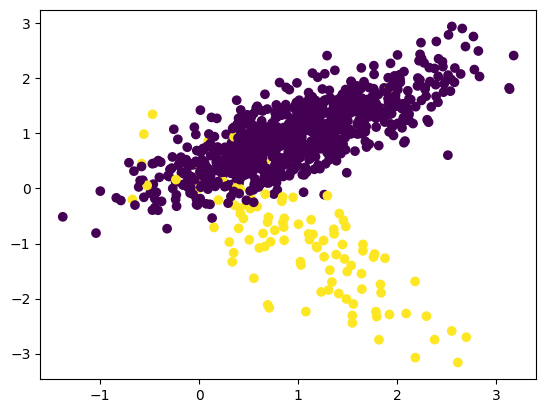

In [ ]:
import matplotlib.pyplot as plt
# final_df['f1'] → values for the x-axis
# final_df['f2'] → values for the y-axis
# c=final_df['target'] → color of each point based on its class labele
plt.scatter(final_df['f1'], final_df['f2'],c = final_df['target']) # for x-axis -> f1 , for y-axis -> f2
                        # c = final_df['target']) -> It means 0 ko xutai color and 1 ko xutai color differential gardinxa.

# imblearn
* Python library called imbalanced-learn.
# Why install it
* Because standard libraries like scikit-learn don’t include advanced imbalance techniques such as:

* SMOTE
* ADASYN
* Random over/under sampling (more flexible versions)

So imblearn fills that gap.
* After installing, you can:

1. Handle imbalanced data easily
* from imblearn.over_sampling import SMOTE
2. Create balanced datasets
* oversample = SMOTE()
* X_resampled, y_resampled = oversample.fit_resample(X, y)
3. Use pipelines with resampling
* from imblearn.pipeline import Pipeline

# Why this matters

In real datasets:

* One class might be very rare (fraud, disease, spam)
Models tend to ignore minority class

imblearn helps fix that by:

* Generating synthetic data (SMOTE)
Balancing class distribution
* Improving model performance on minority cases

# Simple analogy
* Without imblearn → model sees mostly one class
* With imblearn → model gets a fair view of both classes


In [ ]:
pip install imblearn

In [ ]:
# Handle imbalanced data easily
from imblearn.over_sampling import SMOTE

In [ ]:
# This line (SMOTE applied). transform the dataset
oversample = SMOTE()
# x_resampled, y_resampled = oversample.fit_resample(x, y)
x,y = oversample.fit_resample(final_df[['f1','f2']], final_df['target']) # f1 and f2 is input and final_df['target'] is output.


In [ ]:
x.shape # 1758 rows and 2 features(f1, f2)

(1788, 2)

In [ ]:
y.shape # 1788 target values

(1788,)

In [ ]:
# After SMOTE
# class 0 = 894
1788 / 2 # class 0 = 894 It means the class 0 appears 894 times.


894.0

In [ ]:
y == 0

,target
0,False
1,True
2,True
3,True
4,True
...,...
1783,False
1784,False
1785,False
1786,False


In [ ]:
y[y == 0]

,target
1,0
2,0
3,0
4,0
5,0
...,...
995,0
996,0
997,0
998,0


In [ ]:
len(y[y == 0])

894

In [ ]:
len(y[y == 1])

894

# 1️⃣ This line (SMOTE applied)
* x, y = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

  Meaning:
  * final_df[['f1','f2']] → input features (x)
  * final_df['target'] → labels (y)
  * SMOTE creates new synthetic minority samples

After this:

  * x = new feature dataset
  * y = new balanced target values
# 2️⃣ This output
x.shape
 *  (1788, 2)

# Meaning:
  * 1788 rows (data points)
  * 2 columns (f1, f2)

 # Originally had ~1000 rows
 #  After SMOTE → increased to 1788

# 3️⃣ This line
1788 / 2
# 894
# Meaning:

 checking how many samples per class.

 Since SMOTE balances classes:

* Class 0 → 894
* Class 1 → 894

✔️ Perfectly balanced dataset

# 4️⃣ This line
y[y == 0]
# Meaning:

This is filtering all rows where class = 0

 Output shows:

* Only class 0 values
* Total rows = 894

So it confirms:
* ✔️ Class 0 count = 894

# 5️⃣ This line
len(y[y == 0])
# Meaning:

 Counts number of class 0 samples

# Result:

894
 *  Big Picture (achieved)

# Before SMOTE:

    * Class 0 → ~900
    * Class 1 → ~100

 # After SMOTE:

   * Class 0 → 894
   * Class 1 → 894

  DATASET IS NOW BALANCED




In [ ]:
import pandas as pd
df1 = pd.DataFrame(x,columns = ['f1','f2']) # puting x value in f1 and f2 column
df2 = pd.DataFrame(y,columns = ['target'])  # puting y value in target column
oversample_df = pd.concat([df1,df2], axis=1)

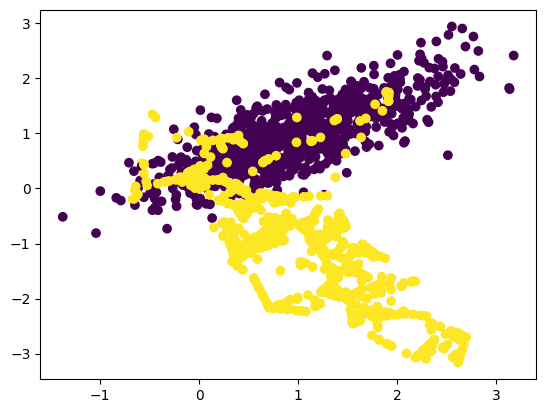

In [ ]:
# Making data interpolation
plt.scatter(oversample_df['f1'], oversample_df['f2'],c = oversample_df['target'])

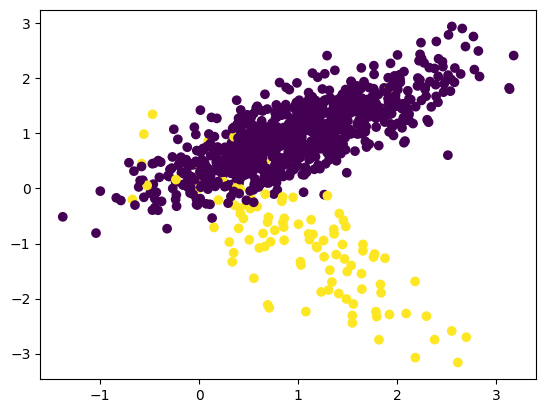

In [ ]:
plt.scatter(final_df['f1'], final_df['f2'],c = final_df['target'])